# Customer Churn

## 1.Data Exploratory

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
# from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, classification_report

from sklearn.preprocessing import PowerTransformer
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_excel('E Commerce Dataset.xlsx', sheet_name='E Comm')
df.head()

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60


In [3]:
df.shape

(5630, 20)

In [4]:
df.columns

Index(['CustomerID', 'Churn', 'Tenure', 'PreferredLoginDevice', 'CityTier',
       'WarehouseToHome', 'PreferredPaymentMode', 'Gender', 'HourSpendOnApp',
       'NumberOfDeviceRegistered', 'PreferedOrderCat', 'SatisfactionScore',
       'MaritalStatus', 'NumberOfAddress', 'Complain',
       'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount',
       'DaySinceLastOrder', 'CashbackAmount'],
      dtype='object')

**CustomerID**: A unique identifier for each customer, often used to track individual
records.

**Churn**: Indicates whether the customer has left the service (churned) or not.
It'stypically a binary variable: 1 for churn and 0 for active customers.

**Tenure**: Represents the number of months the customer has been using the
service. A higher tenure often reflects customer loyalty.

**PreferredLoginDevice:** Specifies the device (e.g., mobile, desktop, tablet) that
the customer uses most frequently to log into the service.

**CityTier:** Refers to the classification of the city where the customer lives, often
based on economic activity or population size (e.g., Tier 1 for major cities, Tier 2
for smaller cities).

**WarehouseToHome:** Measures the distance (in kilometers or miles) between the
customer's home and the nearest warehouse of the service provider. It could
influence delivery times or satisfaction.

**PreferredPaymentMode:** Indicates the customer's chosen payment method,
such as credit card, cash on delivery, or online payment gateways.

**Gender:** The gender of the customer (e.g., Male, Female, or other categories).

**HourSpendOnApp:** The average number of hours the customer spends on the
app (per day or month). More hours might indicate higher engagement.

**NumberOfDeviceRegistered:** Counts the total number of devices (e.g., mobile
phones, tablets) the customer has linked to their account.
    
**PreferedOrderCat:** Refers to the category of products that the customer prefers
to order, like electronics, groceries, clothing, etc.

**SatisfactionScore:** A numerical rating (e.g., 1 to 5 or 1 to 10) that reflects how
satisfied the customer is with the service.

**MaritalStatus:** Indicates whether the customer is single, married, divorced, etc. It
might relate to customer preferences or spending habits.

**NumberOfAddress:** The number of addresses the customer has registered with
the service (e.g., home, work, or alternate delivery addresses).

**Complain:** A binary value (e.g., 1 or 0) indicating whether the customer has
lodged a complaint about the service.

**OrderAmountHikeFromlastYear:** The percentage increase in the amount spent
on orders compared to the previous year, which shows spending trends.

**CouponUsed:** Counts how many coupons the customer has used for discounts or
promotions in the service.
                                                    
**OrderCount:** The total number of orders the customer has placed on the
platform.

**DaySinceLastOrder:** The number of days since the customer last placed an order.
Higher values might indicate disengagement.

**CashbackAmount:** The total cashback amount (usually in currency terms) that
the customer has received from using the service.

### **1.1 Handling Duplicates & Missing Values**

In [5]:
df.duplicated().sum()

0

In [6]:
df.isnull().sum()

CustomerID                       0
Churn                            0
Tenure                         264
PreferredLoginDevice             0
CityTier                         0
WarehouseToHome                251
PreferredPaymentMode             0
Gender                           0
HourSpendOnApp                 255
NumberOfDeviceRegistered         0
PreferedOrderCat                 0
SatisfactionScore                0
MaritalStatus                    0
NumberOfAddress                  0
Complain                         0
OrderAmountHikeFromlastYear    265
CouponUsed                     256
OrderCount                     258
DaySinceLastOrder              307
CashbackAmount                   0
dtype: int64

In [7]:
df.dtypes

CustomerID                       int64
Churn                            int64
Tenure                         float64
PreferredLoginDevice            object
CityTier                         int64
WarehouseToHome                float64
PreferredPaymentMode            object
Gender                          object
HourSpendOnApp                 float64
NumberOfDeviceRegistered         int64
PreferedOrderCat                object
SatisfactionScore                int64
MaritalStatus                   object
NumberOfAddress                  int64
Complain                         int64
OrderAmountHikeFromlastYear    float64
CouponUsed                     float64
OrderCount                     float64
DaySinceLastOrder              float64
CashbackAmount                 float64
dtype: object

In [8]:
for i in df.columns:
    if df[i].dtypes == 'object':
        print(i)
        print()
        print('the values are:')
        print(df[i].value_counts())
        print()
        print()

PreferredLoginDevice

the values are:
PreferredLoginDevice
Mobile Phone    2765
Computer        1634
Phone           1231
Name: count, dtype: int64


PreferredPaymentMode

the values are:
PreferredPaymentMode
Debit Card          2314
Credit Card         1501
E wallet             614
UPI                  414
COD                  365
CC                   273
Cash on Delivery     149
Name: count, dtype: int64


Gender

the values are:
Gender
Male      3384
Female    2246
Name: count, dtype: int64


PreferedOrderCat

the values are:
PreferedOrderCat
Laptop & Accessory    2050
Mobile Phone          1271
Fashion                826
Mobile                 809
Grocery                410
Others                 264
Name: count, dtype: int64


MaritalStatus

the values are:
MaritalStatus
Married     2986
Single      1796
Divorced     848
Name: count, dtype: int64




In [9]:
for i in df.columns:
    if df[i].isnull().sum() > 0:
        print(i)
        print('the total null values are:', df[i].isnull().sum())
        print('the datatype is', df[i].dtypes)
        print()

Tenure
the total null values are: 264
the datatype is float64

WarehouseToHome
the total null values are: 251
the datatype is float64

HourSpendOnApp
the total null values are: 255
the datatype is float64

OrderAmountHikeFromlastYear
the total null values are: 265
the datatype is float64

CouponUsed
the total null values are: 256
the datatype is float64

OrderCount
the total null values are: 258
the datatype is float64

DaySinceLastOrder
the total null values are: 307
the datatype is float64



In [10]:
numerical_cols = df.select_dtypes(include=['number']).columns.tolist()

categorical_cols = df.select_dtypes(include=['object']).columns.tolist()


In [11]:
num_imputer = SimpleImputer(strategy='mean')
df[numerical_cols] = num_imputer.fit_transform(df[numerical_cols])
cat_imputer = SimpleImputer(strategy='most_frequent')
df[categorical_cols] = cat_imputer.fit_transform(df[categorical_cols])


In [12]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

preprocessor = ColumnTransformer(
    transformers=[
        ('num', SimpleImputer(strategy='mean'), numerical_cols),
        ('cat', SimpleImputer(strategy='most_frequent'), categorical_cols)
    ])

df_imputed = preprocessor.fit_transform(df)


In [13]:
df.isna().sum()

CustomerID                     0
Churn                          0
Tenure                         0
PreferredLoginDevice           0
CityTier                       0
WarehouseToHome                0
PreferredPaymentMode           0
Gender                         0
HourSpendOnApp                 0
NumberOfDeviceRegistered       0
PreferedOrderCat               0
SatisfactionScore              0
MaritalStatus                  0
NumberOfAddress                0
Complain                       0
OrderAmountHikeFromlastYear    0
CouponUsed                     0
OrderCount                     0
DaySinceLastOrder              0
CashbackAmount                 0
dtype: int64

In [14]:
df.sample(10)

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
1816,51817.0,0.0,11.000000,Mobile Phone,1.0,16.0,Credit Card,Female,3.0,3.0,Laptop & Accessory,3.0,Married,4.0,0.0,19.0,0.0,1.0,0.000000,198.24
5436,55437.0,0.0,11.000000,Mobile Phone,3.0,16.0,E wallet,Male,3.0,5.0,Laptop & Accessory,4.0,Married,3.0,0.0,15.0,2.0,2.0,4.000000,166.89
764,50765.0,0.0,10.189899,Phone,1.0,20.0,Debit Card,Male,2.0,3.0,Mobile,5.0,Divorced,2.0,1.0,14.0,2.0,6.0,8.000000,122.35
3560,53561.0,0.0,9.000000,Mobile Phone,3.0,24.0,Debit Card,Male,4.0,4.0,Laptop & Accessory,5.0,Divorced,5.0,1.0,16.0,2.0,2.0,4.543491,214.66
4963,54964.0,0.0,8.000000,Computer,1.0,10.0,Debit Card,Male,3.0,5.0,Mobile Phone,1.0,Married,5.0,0.0,18.0,1.0,2.0,1.000000,154.79
273,50274.0,0.0,10.000000,Computer,1.0,31.0,Credit Card,Female,3.0,3.0,Laptop & Accessory,3.0,Divorced,4.0,1.0,15.0,3.0,10.0,7.000000,144.49
4631,54632.0,0.0,12.000000,Mobile Phone,1.0,17.0,Credit Card,Female,4.0,4.0,Laptop & Accessory,3.0,Married,5.0,0.0,20.0,1.0,2.0,4.543491,223.24
67,50068.0,1.0,0.000000,Mobile Phone,1.0,29.0,Debit Card,Male,2.0,4.0,Laptop & Accessory,3.0,Divorced,4.0,1.0,13.0,1.0,1.0,1.000000,159.16
4971,54972.0,0.0,12.000000,Mobile Phone,3.0,9.0,E wallet,Male,3.0,4.0,Fashion,4.0,Single,9.0,0.0,17.0,2.0,2.0,1.000000,198.51
2166,52167.0,0.0,22.000000,Mobile Phone,3.0,14.0,Cash on Delivery,Male,2.0,4.0,Grocery,4.0,Married,7.0,0.0,17.0,1.0,2.0,4.543491,231.20


### **1.2 Map binary values to meaningful labels**

In [15]:
df['Churn'] = df['Churn'].map({1: 'Churned', 0: 'Not Churned'})
df['Complain'] = df['Complain'].map({1: 'Complain', 0: 'No Complain'})

In [16]:
df['CityTier'] = df['CityTier'].map({1: 'Tier 1 - Metropolitan',
                                     2: 'Tier 2 - Moderate Urban',
                                     3: 'Tier 3 - Rural/Small Town'})

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   5630 non-null   float64
 1   Churn                        5630 non-null   object 
 2   Tenure                       5630 non-null   float64
 3   PreferredLoginDevice         5630 non-null   object 
 4   CityTier                     5630 non-null   object 
 5   WarehouseToHome              5630 non-null   float64
 6   PreferredPaymentMode         5630 non-null   object 
 7   Gender                       5630 non-null   object 
 8   HourSpendOnApp               5630 non-null   float64
 9   NumberOfDeviceRegistered     5630 non-null   float64
 10  PreferedOrderCat             5630 non-null   object 
 11  SatisfactionScore            5630 non-null   float64
 12  MaritalStatus                5630 non-null   object 
 13  NumberOfAddress   

In [18]:
df.drop(['CustomerID'],axis=1, inplace=True)

### **1.3 Data Description**

In [19]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Tenure,5630.0,10.189899,8.354164,0.0,3.00,9.00,15.000000,61.00
WarehouseToHome,5630.0,15.639896,8.339095,5.0,9.00,14.00,20.000000,127.00
HourSpendOnApp,5630.0,2.931535,0.705384,0.0,2.00,3.00,3.000000,5.00
NumberOfDeviceRegistered,5630.0,3.688988,1.023999,1.0,3.00,4.00,4.000000,6.00
SatisfactionScore,5630.0,3.066785,1.380194,1.0,2.00,3.00,4.000000,5.00
NumberOfAddress,5630.0,4.214032,2.583586,1.0,2.00,3.00,6.000000,22.00
OrderAmountHikeFromlastYear,5630.0,15.707922,3.587926,11.0,13.00,15.00,18.000000,26.00
CouponUsed,5630.0,1.751023,1.851038,0.0,1.00,1.00,2.000000,16.00
OrderCount,5630.0,3.008004,2.871521,1.0,1.00,2.00,3.008004,16.00
DaySinceLastOrder,5630.0,4.543491,3.553382,0.0,2.00,4.00,7.000000,46.00


## **2.Data Analysis & Visualizations**

### **2.1.Basic Visualizations**

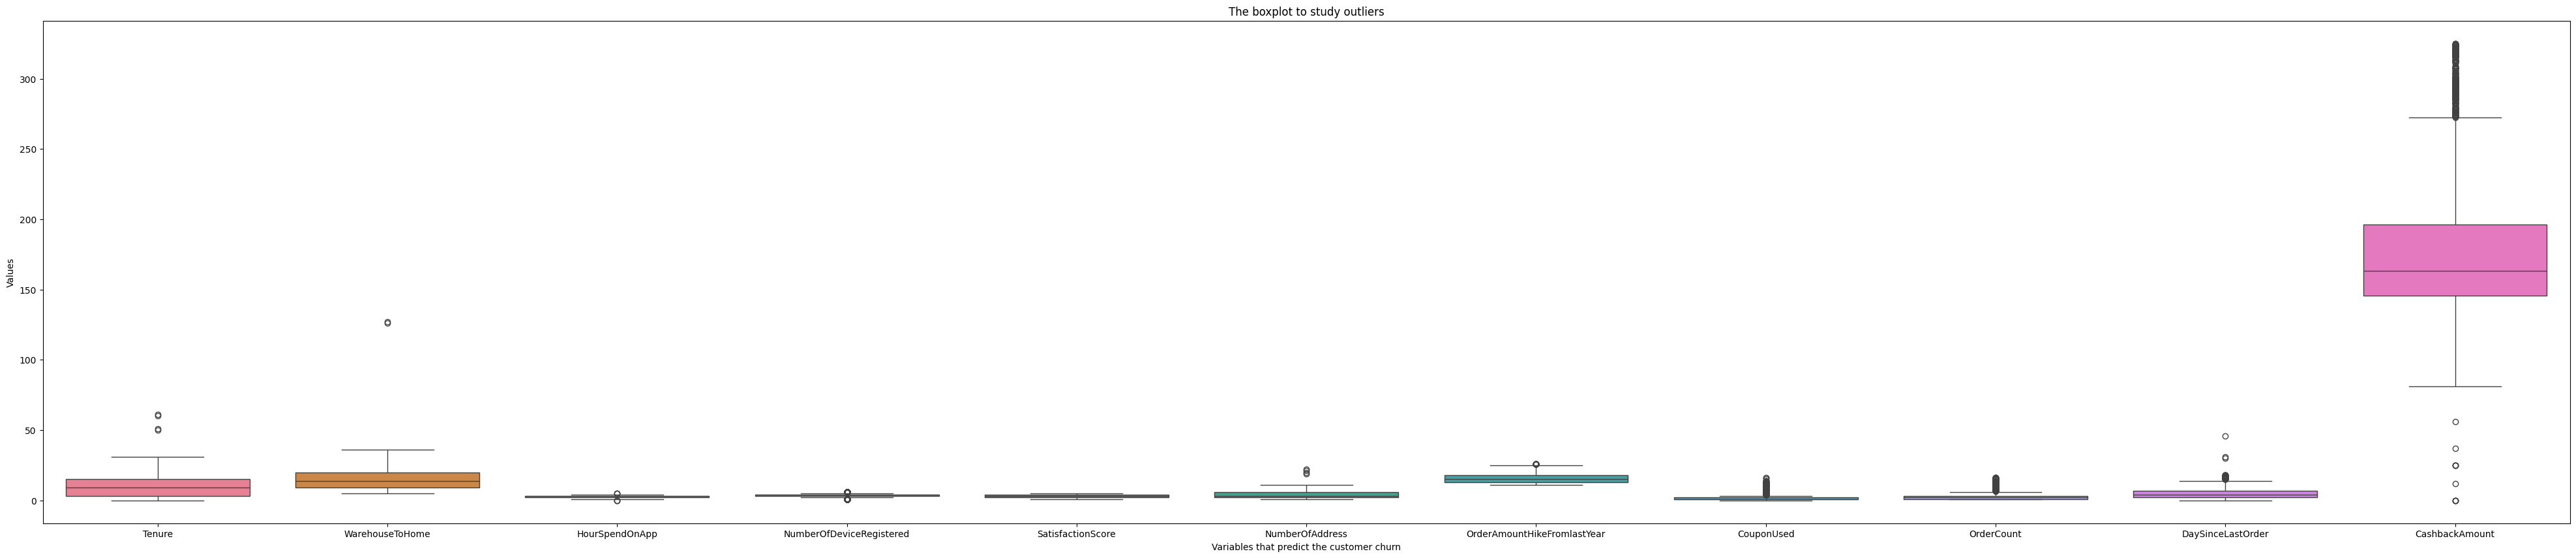

In [20]:
plt.figure(figsize=(50,10))
sns.boxplot(data=df)
plt.title('The boxplot to study outliers')
plt.xlabel('Variables that predict the customer churn')
plt.ylabel('Values')
plt.show()

In [21]:
def clip_outlier(col):
    sorted(col)
    Q1,Q3=np.percentile(col,[25,75])
    IQR=Q3-Q1
    lr= Q1-(1.5 * IQR)
    ur= Q3+(1.5 * IQR)
    return lr, ur

In [22]:
for column in df.columns:
    if df[column].dtype != 'object':
        lr,ur=clip_outlier(df[column])
        df[column]=np.where(df[column]>ur,ur,df[column])
        df[column]=np.where(df[column]<lr,lr,df[column])

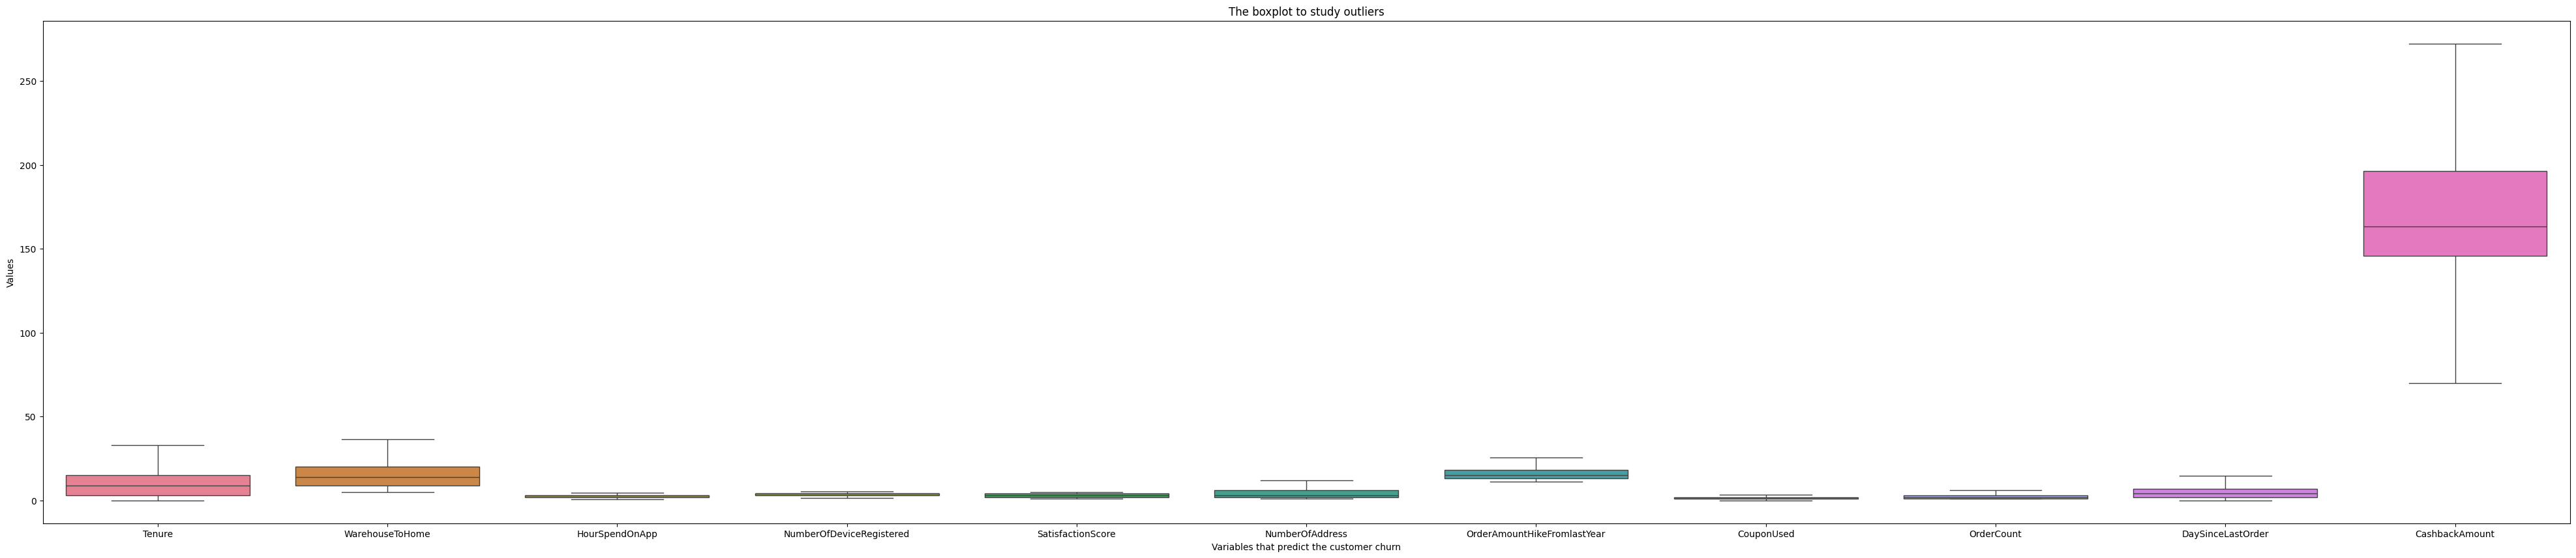

In [23]:
plt.figure(figsize=(50,10))
sns.boxplot(data=df)
plt.title('The boxplot to study outliers')
plt.xlabel('Variables that predict the customer churn')
plt.ylabel('Values')
plt.show()

### **2.2.Distribution plots**

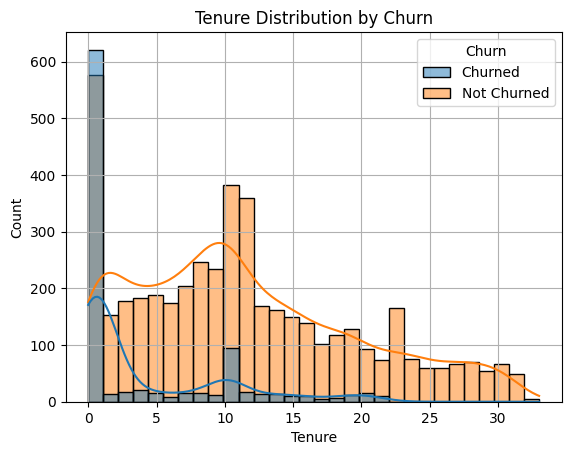

In [24]:
sns.histplot(data=df, x='Tenure', hue='Churn', kde=True, bins=30)
plt.title("Tenure Distribution by Churn")
plt.grid(True)
plt.show()


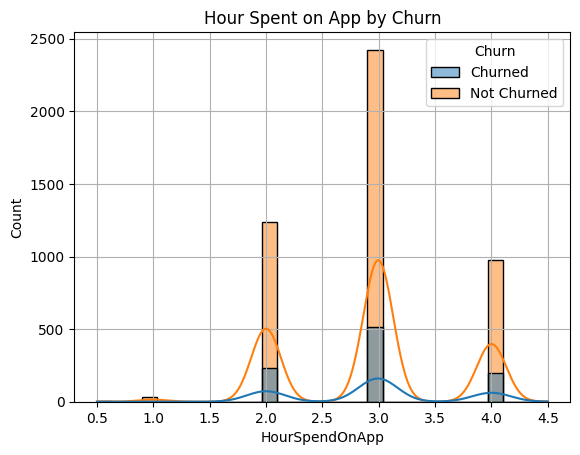

In [25]:
sns.histplot(data=df, x='HourSpendOnApp', hue='Churn', kde=True, bins=30)
plt.title("Hour Spent on App by Churn")
plt.grid(True)
plt.show()


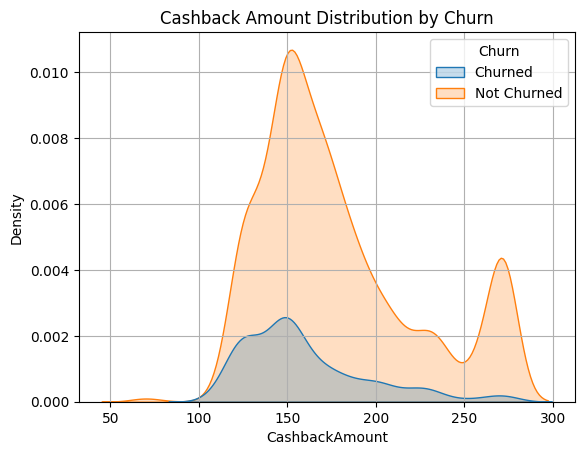

In [26]:
sns.kdeplot(data=df, x='CashbackAmount', hue='Churn', shade=True)
plt.title("Cashback Amount Distribution by Churn")
plt.grid(True)
plt.show()

### **2.3 Comparison Plots**

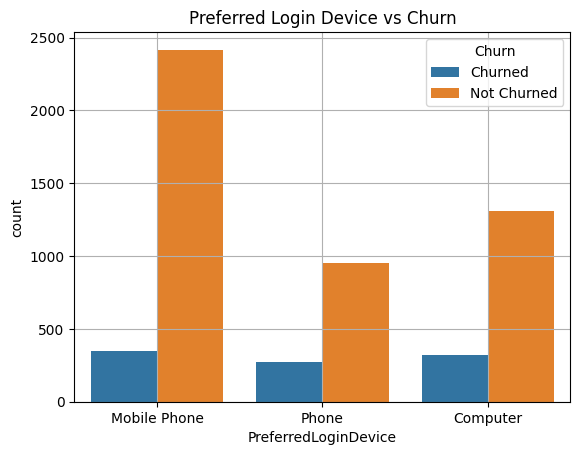

In [27]:
sns.countplot(data=df, x='PreferredLoginDevice', hue='Churn')
plt.title("Preferred Login Device vs Churn")
plt.grid(True)
plt.show()

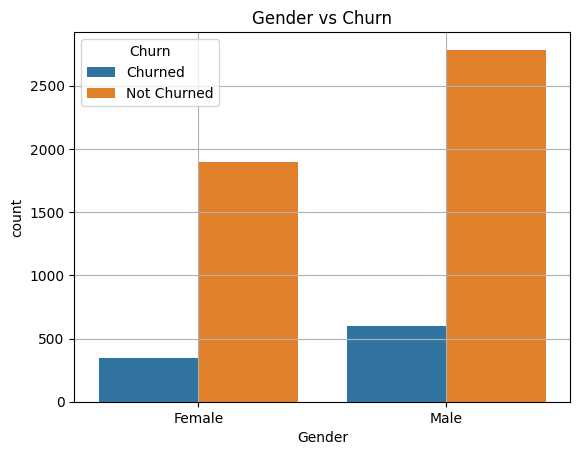

In [28]:
sns.countplot(data=df, x='Gender', hue='Churn')
plt.title("Gender vs Churn")
plt.grid(True)
plt.show()

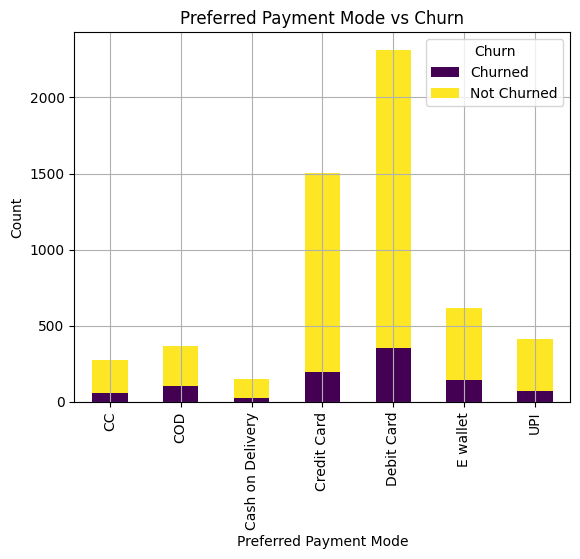

In [29]:
crosstab = pd.crosstab(df['PreferredPaymentMode'], df['Churn'])
crosstab.plot(kind='bar', stacked=True, colormap='viridis')
plt.title("Preferred Payment Mode vs Churn")
plt.xlabel("Preferred Payment Mode")
plt.ylabel("Count")
plt.grid(True)
plt.show()

### **2.4 Realtionship Plots**

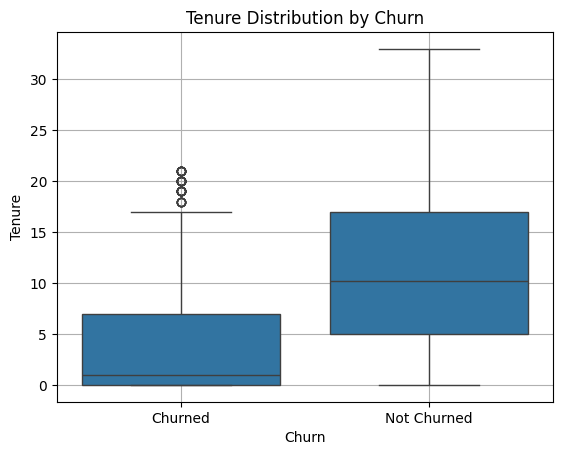

In [30]:
sns.boxplot(data=df, x='Churn', y='Tenure')
plt.title("Tenure Distribution by Churn")
plt.grid(True)
plt.show()

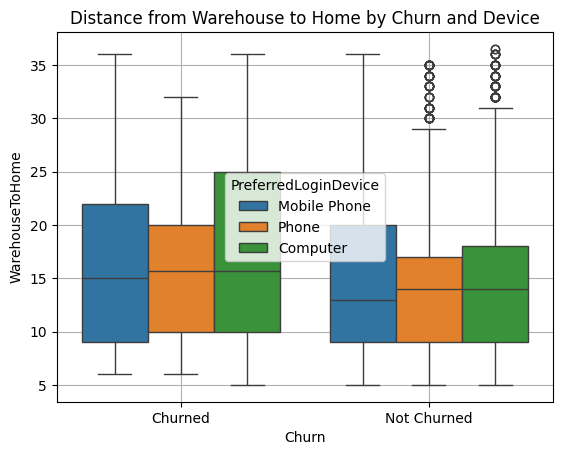

In [31]:
sns.boxplot(data=df, x='Churn', y='WarehouseToHome', hue='PreferredLoginDevice')
plt.title("Distance from Warehouse to Home by Churn and Device")
plt.grid(True)
plt.show()

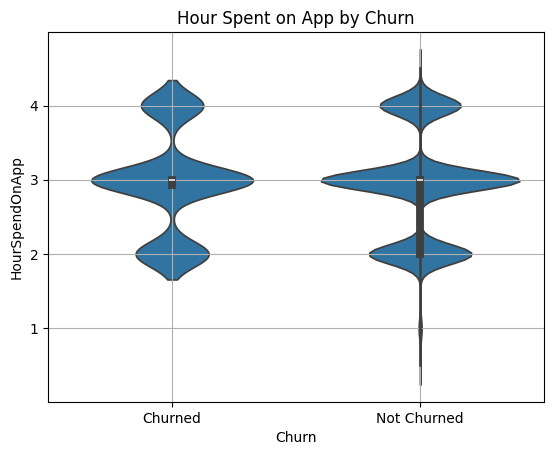

In [32]:
sns.violinplot(data=df, x='Churn', y='HourSpendOnApp')
plt.title("Hour Spent on App by Churn")
plt.grid(True)
plt.show()

### **2.5 Aggregated Insights**

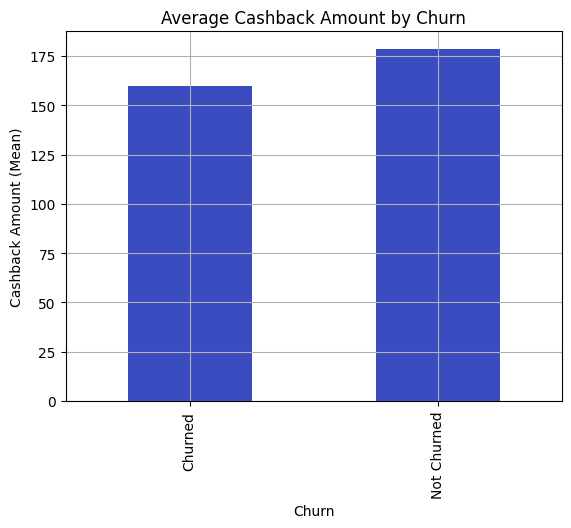

In [33]:
grouped = df.groupby('Churn')['CashbackAmount'].mean()
grouped.plot(kind='bar', colormap='coolwarm')
plt.title("Average Cashback Amount by Churn")
plt.ylabel("Cashback Amount (Mean)")
plt.grid(True)
plt.show()

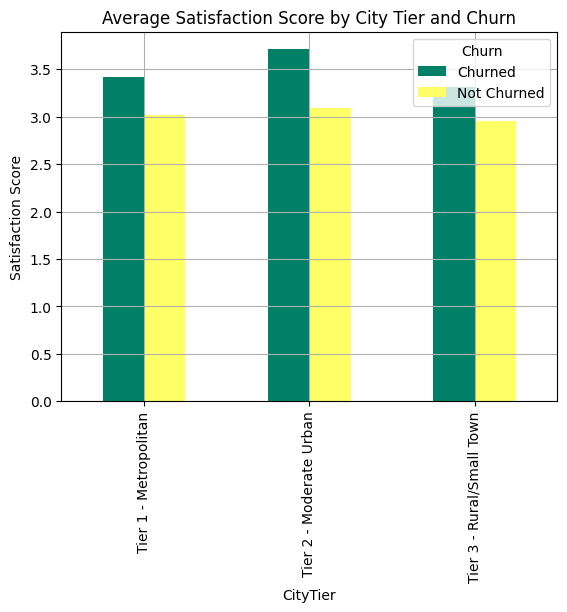

In [34]:
pivot = df.pivot_table(index='CityTier', columns='Churn', values='SatisfactionScore', aggfunc='mean')
pivot.plot(kind='bar', colormap='summer')
plt.title("Average Satisfaction Score by City Tier and Churn")
plt.ylabel("Satisfaction Score")
plt.grid(True)
plt.show()

### **2.6 Relation Plots**

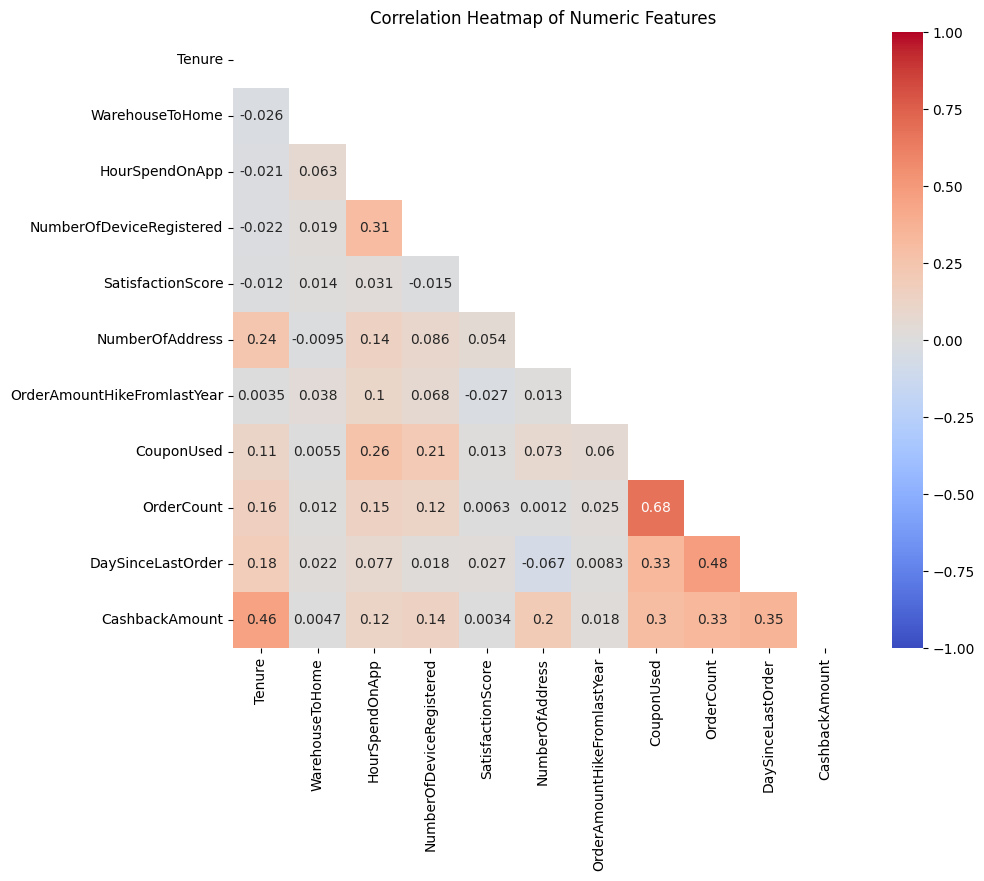

In [35]:

numeric_cols = [
    'Tenure', 'WarehouseToHome', 'HourSpendOnApp', 'NumberOfDeviceRegistered',
    'SatisfactionScore', 'NumberOfAddress', 'OrderAmountHikeFromlastYear',
    'CouponUsed', 'OrderCount', 'DaySinceLastOrder', 'CashbackAmount'
]

corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0, mask=mask)
plt.title('Correlation Heatmap of Numeric Features')
plt.show()

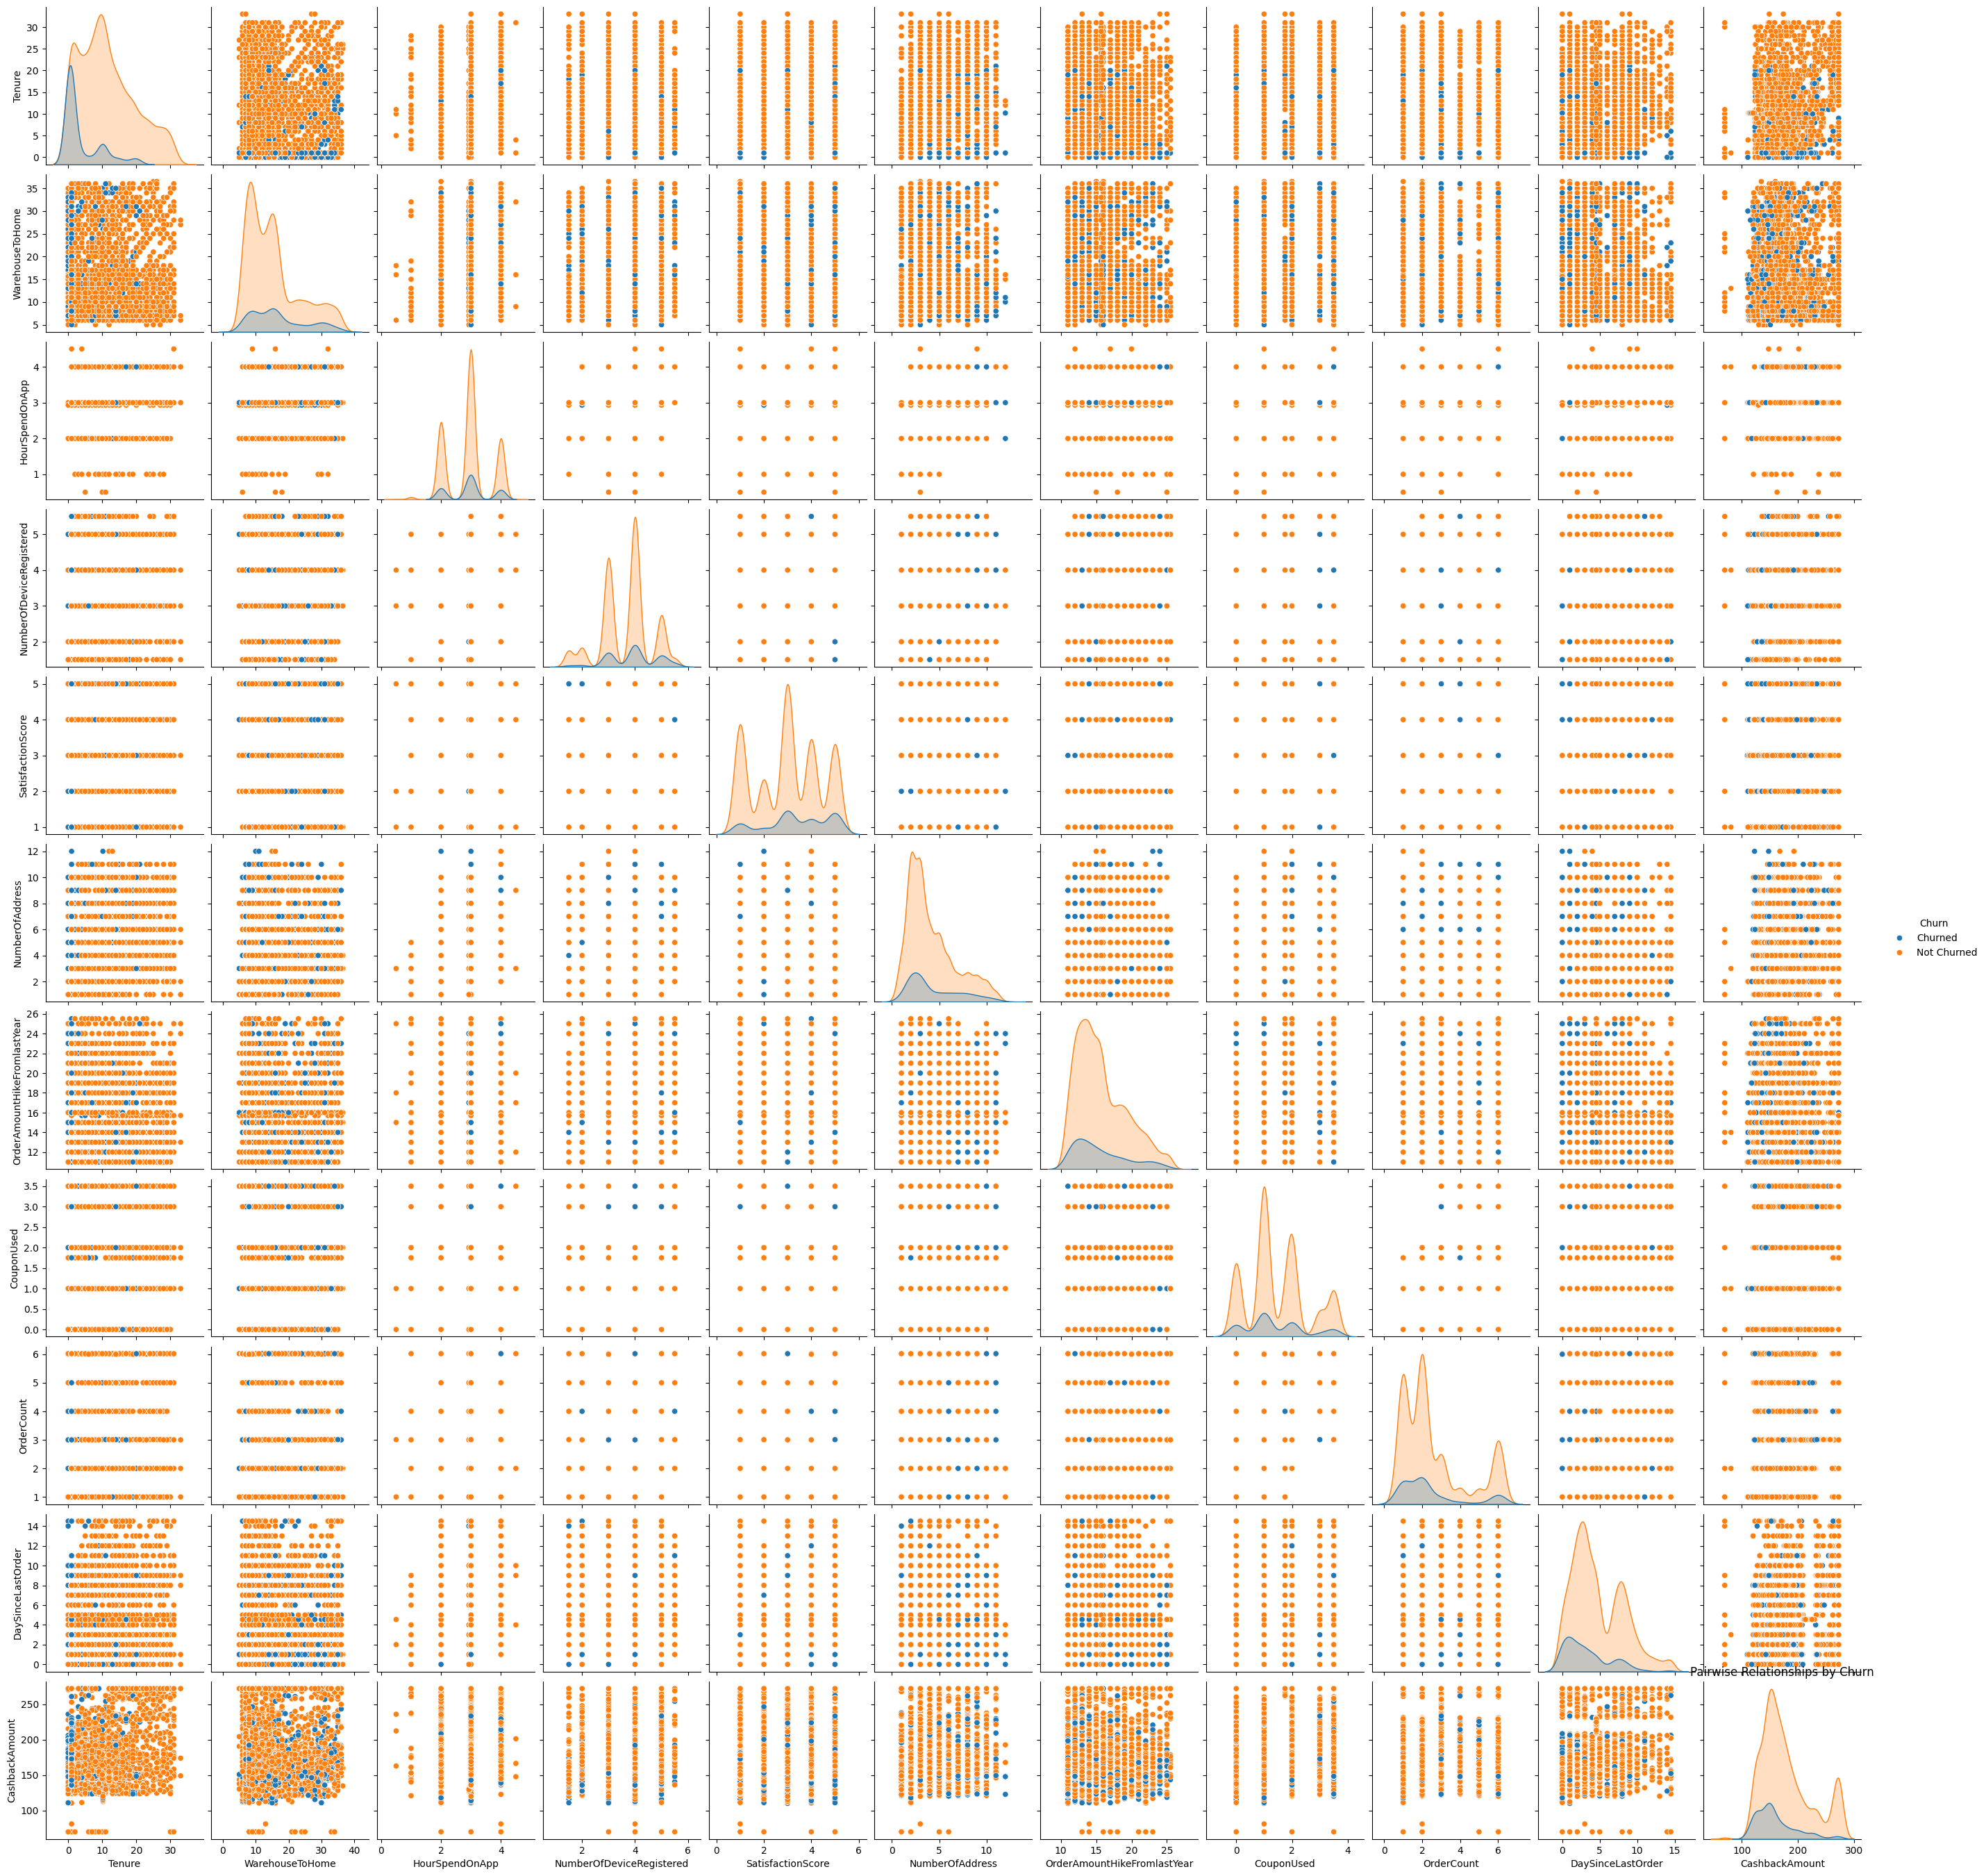

In [36]:
sns.pairplot(df, hue='Churn', vars=numeric_cols)
plt.title("Pairwise Relationships by Churn")
plt.show()

### **2.7 Churn Ratios**

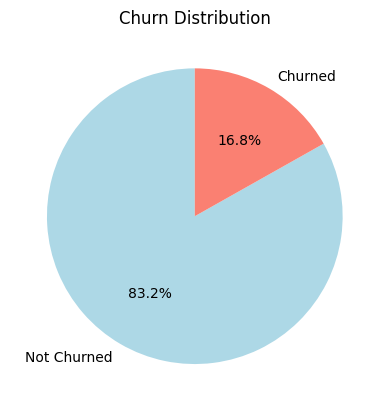

In [37]:
churn_counts = df['Churn'].value_counts()
plt.pie(churn_counts, labels=['Not Churned', 'Churned'], autopct='%1.1f%%', startangle=90, colors=['lightblue', 'salmon'])
plt.title("Churn Distribution")
plt.show()

\


### **2.10 Clustered Heatmap**

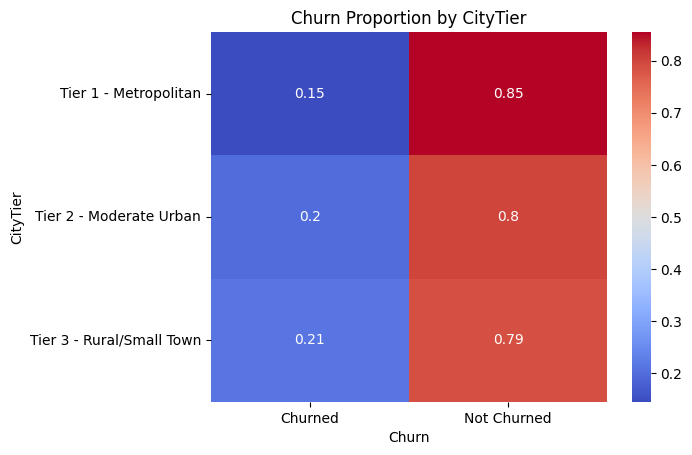

In [38]:
pivot_table = pd.crosstab(df['CityTier'], df['Churn'], normalize='index')
sns.heatmap(pivot_table, annot=True, cmap='coolwarm')
plt.title("Churn Proportion by CityTier")
plt.show()

### **2.11 Bubble Chart**

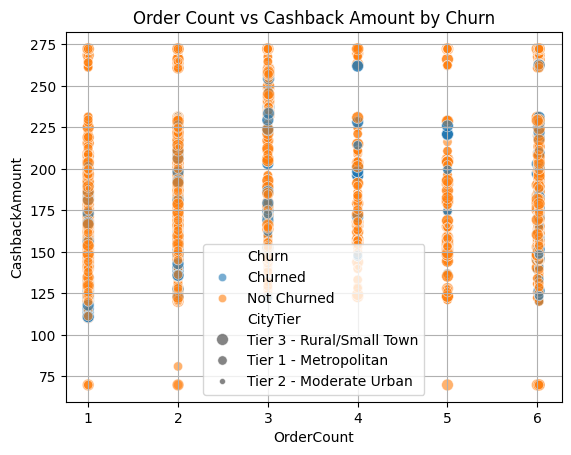

In [39]:
sns.scatterplot(data=df, x='OrderCount', y='CashbackAmount', size='CityTier', hue='Churn', alpha=0.6)
plt.title("Order Count vs Cashback Amount by Churn")
plt.grid(True)
plt.show()

### **2.12 Cohort Analysis**

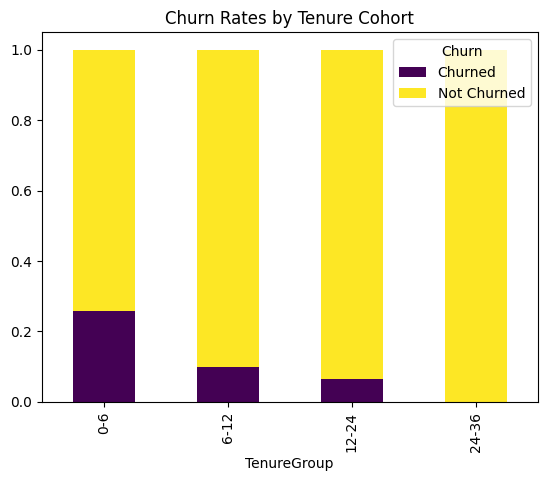

In [40]:
df['TenureGroup'] = pd.cut(df['Tenure'], bins=[0, 6, 12, 24, 36], labels=['0-6', '6-12', '12-24', '24-36'])
churn_rates = df.groupby('TenureGroup')['Churn'].value_counts(normalize=True).unstack()

churn_rates.plot(kind='bar', stacked=True, colormap='viridis')
plt.title("Churn Rates by Tenure Cohort")
plt.show()

## **3. Machine Learning Pre-Processing**

### **3.1 Remapping Previously Mapped Columns**

In [41]:
df['Churn'] = df['Churn'].map({'Not Churned': 0, 'Churned': 1})

df['Complain'] = df['Complain'].map({'No Complain': 0, 'Complain': 1})

df['CityTier'] = df['CityTier'].map({'Tier 1 - Metropolitan': 1,
                                     'Tier 2 - Moderate Urban': 2,
                                     'Tier 3 - Rural/Small Town': 3})

### **3.2 One Hot-Encoder**

In [42]:
df = pd.get_dummies(df, columns=['PreferredLoginDevice', 'PreferredPaymentMode',
                                 'Gender', 'PreferedOrderCat', 'MaritalStatus'], drop_first=True)

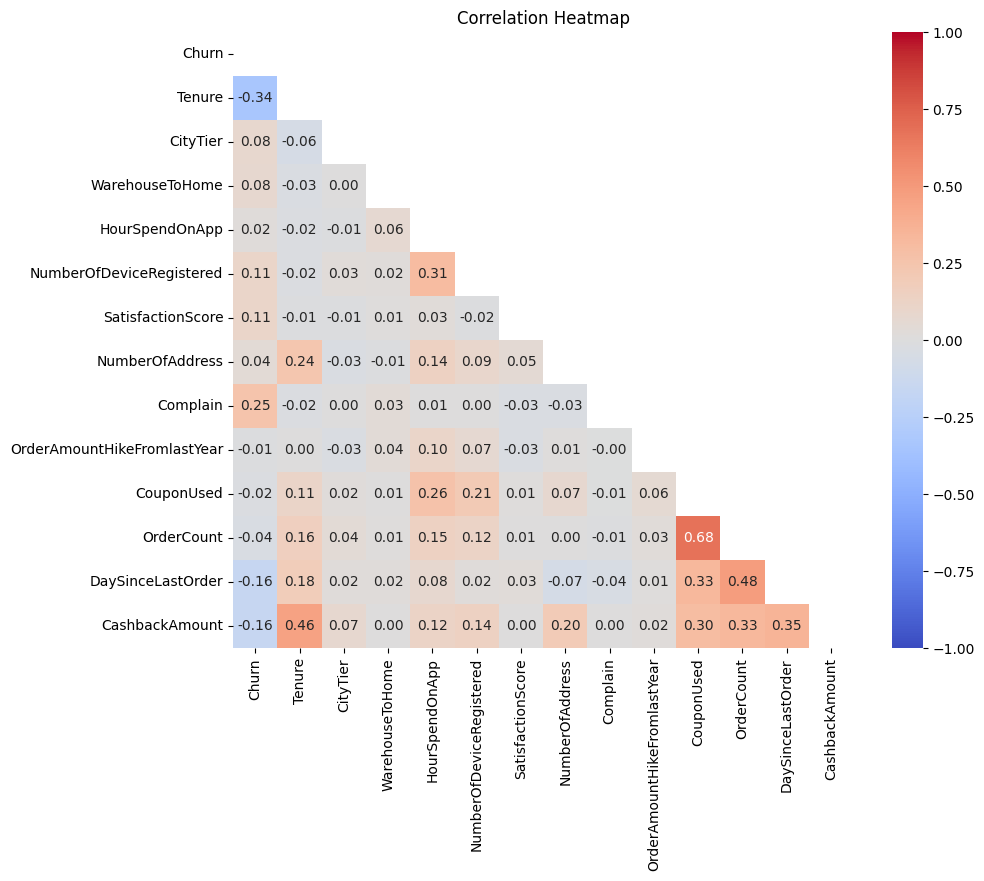

In [43]:
numerical_data = df.select_dtypes(include=['int64', 'float64'])

correlation_matrix = numerical_data.corr()

plt.figure(figsize=(10, 8))
mask=np.triu(np.ones_like(correlation_matrix,dtype=bool))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1,mask=mask)
plt.title("Correlation Heatmap")
plt.show()


### **3.3 Feature Scaling**

In [44]:
df = df.drop(columns=['TenureGroup'], errors='ignore')

print("Columns after dropping TenureGroup:", df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 30 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Churn                                  5630 non-null   int64  
 1   Tenure                                 5630 non-null   float64
 2   CityTier                               5630 non-null   int64  
 3   WarehouseToHome                        5630 non-null   float64
 4   HourSpendOnApp                         5630 non-null   float64
 5   NumberOfDeviceRegistered               5630 non-null   float64
 6   SatisfactionScore                      5630 non-null   float64
 7   NumberOfAddress                        5630 non-null   float64
 8   Complain                               5630 non-null   int64  
 9   OrderAmountHikeFromlastYear            5630 non-null   float64
 10  CouponUsed                             5630 non-null   float64
 11  Orde

### **3.4 Splitting**

In [45]:
X = df.drop(columns=[ 'Churn'])
y = df['Churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
numerical_cols = X_train.select_dtypes(include=np.number).columns


## I am using Yeo-Johnson transformation because some of my numerical features were highly skewed. It helps in reducing skewness and making the data more normally distributed, which improves the performance of linear models. Also, I chose Yeo-Johnson instead of Box-Cox because it works with zero and negative values.

In [46]:
from sklearn.preprocessing import PowerTransformer

pt = PowerTransformer(method="yeo-johnson")

X_train[numerical_cols] = pt.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = pt.transform(X_test[numerical_cols])

## **4.Machine Learning**

### **4.1 Traing Models Before Feature Selection**

#### 4.1.2 Logistic Regression

In [47]:
lr_model = LogisticRegression(random_state=42)
lr_model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [48]:
lr_preds = lr_model.predict(X_test)
print(classification_report(y_test,lr_preds))


              precision    recall  f1-score   support

           0       0.92      0.97      0.94      1414
           1       0.76      0.56      0.65       275

    accuracy                           0.90      1689
   macro avg       0.84      0.76      0.79      1689
weighted avg       0.89      0.90      0.89      1689



**Confusion Matrix**

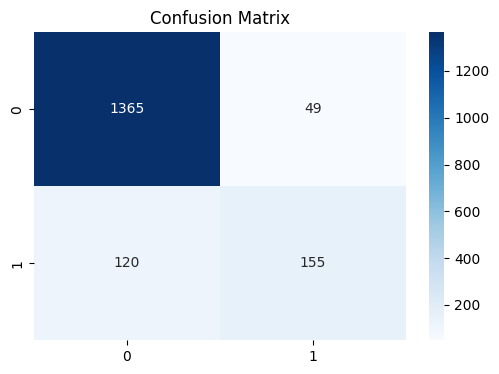

In [49]:
corr=confusion_matrix(y_test,lr_preds)
plt.figure(figsize=(6,4))
sns.heatmap(corr,annot=True,cmap='Blues',fmt='.0f')
plt.title('Confusion Matrix')
plt.show()

**Bias & Varience Trade Off**

In [50]:
lr_preds = np.array(y)

variance = np.var(lr_preds)

mse = np.mean((y - np.mean(lr_preds))**2)

bias_squared = np.mean((np.mean(lr_preds) - y)**2)

total_error = bias_squared + variance

In [51]:
print(f"Variance: {variance}")
print(f"Bias Squared: {bias_squared}")
print(f"Total Error: {total_error}")

Variance: 0.14003060236174517
Bias Squared: 0.14003060236174517
Total Error: 0.28006120472349033


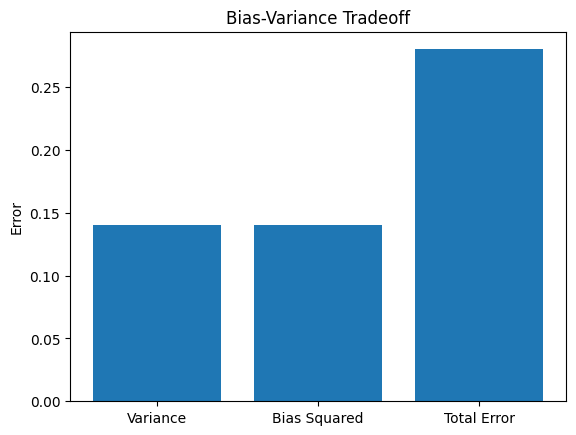

In [52]:
plt.bar(['Variance', 'Bias Squared', 'Total Error'], [variance, bias_squared, total_error])
plt.title('Bias-Variance Tradeoff')
plt.ylabel('Error')
plt.show()

**Cross Validation & Error Estimation**

In [53]:
model = LogisticRegression(random_state=42)

skfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = []

for train_index, val_index in skfold.split(X_train, y_train):
    X_train_fold, X_val_fold = X_train.iloc[train_index], X_train.iloc[val_index]
    y_train_fold, y_val_fold = y_train.iloc[train_index], y_train.iloc[val_index]

    model.fit(X_train_fold, y_train_fold)

    y_pred = model.predict(X_val_fold)

    cv_results.append(accuracy_score(y_val_fold, y_pred))

print(f"Cross-validation accuracies: {cv_results}")
print(f"Mean CV accuracy: {sum(cv_results) / len(cv_results):.4f}")
print(f"Standard deviation: {np.std(cv_results):.4f}")

Cross-validation accuracies: [0.9036755386565273, 0.8845177664974619, 0.8934010152284264, 0.8781725888324873, 0.8946700507614214]
Mean CV accuracy: 0.8909
Standard deviation: 0.0088


## 2.3 Logistic Regression with Balanced Class Weight

In [54]:
lr_balanced = LogisticRegression(class_weight='balanced', random_state=42)
lr_balanced.fit(X_train, y_train)

lrb_preds = lr_balanced.predict(X_test)
print("Classification Report (Balanced Class Weight):")
print(classification_report(y_test, lrb_preds))

Classification Report (Balanced Class Weight):
              precision    recall  f1-score   support

           0       0.96      0.83      0.89      1414
           1       0.48      0.80      0.60       275

    accuracy                           0.83      1689
   macro avg       0.72      0.82      0.75      1689
weighted avg       0.88      0.83      0.84      1689



**Comparison: Default vs. Balanced Logistics Weights**

In [55]:
from sklearn.metrics import precision_score, recall_score, f1_score

# 1. Re-generate test predictions to ensure length matches y_test (1689 samples)
lr_preds_test = lr_model.predict(X_test)
lrb_preds_test = lr_balanced.predict(X_test)

# 2. Calculate scores
orig_p = precision_score(y_test, lr_preds_test, pos_label=1)
orig_r = recall_score(y_test, lr_preds_test, pos_label=1)
orig_f1 = f1_score(y_test, lr_preds_test, pos_label=1)

bal_p = precision_score(y_test, lrb_preds_test, pos_label=1)
bal_r = recall_score(y_test, lrb_preds_test, pos_label=1)
bal_f1 = f1_score(y_test, lrb_preds_test, pos_label=1)

# 3. Create and display comparison
comparison_df = pd.DataFrame({
    'Metric': ['Precision (Class 1)', 'Recall (Class 1)', 'F1 Score (Class 1)'],
    'Logistic Regression (Default)': [orig_p, orig_r, orig_f1],
    'Logistic Regression (Balanced)': [bal_p, bal_r, bal_f1]
})

print("Comparison for Churn Prediction (Class 1):")
display(comparison_df.style.set_caption("Default vs. Balanced Logistic Regression Summary"))


Comparison for Churn Prediction (Class 1):


,Metric,Logistic Regression (Default),Logistic Regression (Balanced)
0,Precision (Class 1),0.759804,0.480435
1,Recall (Class 1),0.563636,0.803636
2,F1 Score (Class 1),0.647182,0.601361


## 3. Random Forest Classifier

In [56]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [57]:
rf_preds = rf_model.predict(X_test)
print(classification_report(y_test, rf_preds))

              precision    recall  f1-score   support

           0       0.96      0.99      0.97      1414
           1       0.93      0.80      0.86       275

    accuracy                           0.96      1689
   macro avg       0.95      0.89      0.92      1689
weighted avg       0.96      0.96      0.96      1689



**Confusion Matrix - Random Forest**

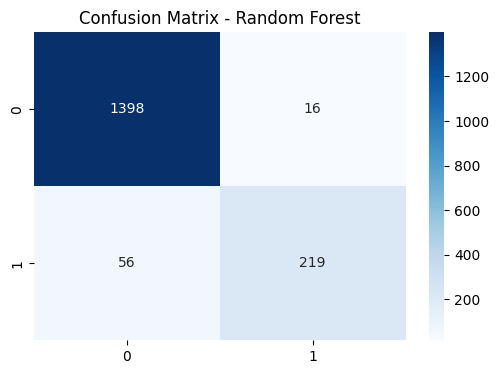

In [58]:
corr_rf = confusion_matrix(y_test, rf_preds)
plt.figure(figsize=(6, 4))
sns.heatmap(corr_rf, annot=True, cmap='Blues', fmt='.0f')
plt.title('Confusion Matrix - Random Forest')
plt.show()

**Cross Validation & Error Estimation - Random Forest**

In [59]:
model_rf = RandomForestClassifier(random_state=42)
skfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results_rf = []

for train_index, val_index in skfold.split(X_train, y_train):
    X_train_fold, X_val_fold = X_train.iloc[train_index], X_train.iloc[val_index]
    y_train_fold, y_val_fold = y_train.iloc[train_index], y_train.iloc[val_index]

    model_rf.fit(X_train_fold, y_train_fold)
    y_pred_rf = model_rf.predict(X_val_fold)
    cv_results_rf.append(accuracy_score(y_val_fold, y_pred_rf))

print(f"Cross-validation accuracies (Random Forest): {cv_results_rf}")
print(f"Mean CV accuracy: {sum(cv_results_rf) / len(cv_results_rf):.4f}")
print(f"Standard deviation: {np.std(cv_results_rf):.4f}")

Cross-validation accuracies (Random Forest): [0.9531051964512041, 0.9454314720812182, 0.9606598984771574, 0.9378172588832487, 0.9365482233502538]
Mean CV accuracy: 0.9467
Standard deviation: 0.0092


##XGBClassifier

In [60]:
from xgboost import XGBClassifier


xgb_model = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

# Predictions and classification report

xgb_preds = xgb_model.predict(X_test)
print("XGBoost Classification Report:")
print(classification_report(y_test, xgb_preds))


XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      1414
           1       0.92      0.87      0.89       275

    accuracy                           0.97      1689
   macro avg       0.95      0.93      0.94      1689
weighted avg       0.97      0.97      0.97      1689



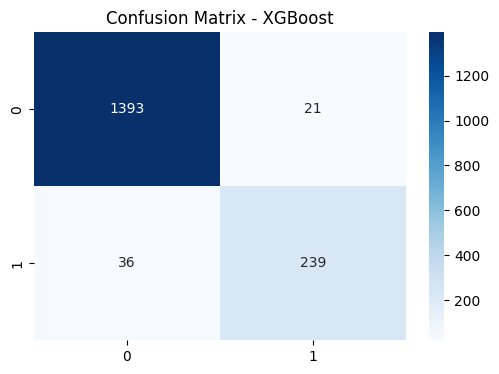

In [61]:
# Plot Confusion Matrix for XGBoost
corr_xgb = confusion_matrix(y_test, xgb_preds)
plt.figure(figsize=(6, 4))
sns.heatmap(corr_xgb, annot=True, cmap='Blues', fmt='.0f')
plt.title('Confusion Matrix - XGBoost')
plt.show()


In [ ]:
# Cross-Validation for XGBoost
model_xgb = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
skfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results_xgb = []

for train_index, val_index in skfold.split(X_train, y_train):
    X_train_fold, X_val_fold = X_train.iloc[train_index], X_train.iloc[val_index]
    y_train_fold, y_val_fold = y_train.iloc[train_index], y_train.iloc[val_index]

    model_xgb.fit(X_train_fold, y_train_fold)
    y_pred_xgb = model_xgb.predict(X_val_fold)
    cv_results_xgb.append(accuracy_score(y_val_fold, y_pred_xgb))

print(f"Cross-validation accuracies (XGBoost): {cv_results_xgb}")
print(f"Mean CV accuracy: {sum(cv_results_xgb) / len(cv_results_xgb):.4f}")
print(f"Standard deviation: {np.std(cv_results_xgb):.4f}")


Cross-validation accuracies (XGBoost): [0.9556400506970849, 0.9479695431472082, 0.9593908629441624, 0.9530456852791879, 0.949238578680203]
Mean CV accuracy: 0.9531
Standard deviation: 0.0042


In [63]:
results = []

models = {
    "Logistic Regression": lr_model,
    "Random Forest": rf_model,
    "XGBoost": xgb_model
}

for name, model in models.items():

    y_pred = model.predict(X_test)

    report = classification_report(y_test, y_pred, output_dict=True)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),

        # Class 0 (Not Churn)
        "Precision_0": report["0"]["precision"],
        "Recall_0": report["0"]["recall"],

        # Class 1 (Churn)
        "Precision_1": report["1"]["precision"],
        "Recall_1": report["1"]["recall"],

        "F1_1": report["1"]["f1-score"]
    })

comparison_df = pd.DataFrame(results)

comparison_df.sort_values(by="Recall_1", ascending=False)

,Model,Accuracy,Precision_0,Recall_0,Precision_1,Recall_1,F1_1
2,XGBoost,0.966252,0.974808,0.985149,0.919231,0.869091,0.893458
1,Random Forest,0.957371,0.961486,0.988685,0.931915,0.796364,0.858824
0,Logistic Regression,0.899941,0.919192,0.965347,0.759804,0.563636,0.647182


##Among all the models evaluated, XGBoost was selected as the final model for deployment.

##Although Random Forest showed strong precision, XGBoost achieved:

##Highest Accuracy (96.6%)

##Highest Recall for churn class (86.9%)

##High##est F1-score

##Since this is a churn prediction problem, detecting churn customers (class 1) is more important than simply maximizing accuracy. XGBoost identifies a significantly higher proportion of churn customers while maintaining strong overall performance.

##Therefore, XGBoost provides the best balance between precision and recall and is chosen for production deployment.

## Production-Ready Pipeline

In [64]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import PowerTransformer
from xgboost import XGBClassifier
import joblib
import numpy as np

# Separate features and target
X = df.drop("Churn", axis=1)
y = df["Churn"]

# Identify column types
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X.select_dtypes(include=["object"]).columns

# Numeric preprocessing
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("power", PowerTransformer(method="yeo-johnson"))
])

# Categorical preprocessing
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# Combine
preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

# Final Pipeline
final_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    ))
])

# Train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Fit pipeline
final_pipeline.fit(X_train, y_train)

# Save full pipeline
joblib.dump(final_pipeline, "churn_pipeline.pkl")

print("Pipeline saved successfully.")

Pipeline saved successfully.


In [66]:
model = joblib.load("churn_pipeline.pkl")

sample_low_risk = pd.DataFrame([{
    "Tenure": 0,
            "CityTier": 3,
            "WarehouseToHome": 60,
            "HourSpendOnApp": 0,
            "NumberOfDeviceRegistered": 1,
            "SatisfactionScore": 1,
            "NumberOfAddress": 1,
            "Complain": 1,
            "OrderAmountHikeFromlastYear": 0,
            "CouponUsed": 0,
            "OrderCount": 0,
            "DaySinceLastOrder": 180,
            "CashbackAmount": 0,
            "PreferredLoginDevice": "Mobile Phone",
            "PreferredPaymentMode": "Cash on Delivery",
            "Gender": "Male",
            "PreferedOrderCat": "Mobile",
            "MaritalStatus": "Single"
}])

pred = model.predict(sample_low_risk)
prob = model.predict_proba(sample_low_risk)

print("Prediction:", "Churn" if pred[0] == 1 else "Not Churn")
print("Churn Probability:", round(prob[0][1] * 100, 2), "%")

Prediction: Churn
Churn Probability: 85.47 %


In [67]:
sample_high_risk = pd.DataFrame([{
    "Tenure": 24,
            "CityTier": 1,
            "WarehouseToHome": 5,
            "HourSpendOnApp": 5,
            "NumberOfDeviceRegistered": 3,
            "SatisfactionScore": 5,
            "NumberOfAddress": 3,
            "Complain": 0,
            "OrderAmountHikeFromlastYear": 15,
            "CouponUsed": 5,
            "OrderCount": 20,
            "DaySinceLastOrder": 5,
            "CashbackAmount": 500,
            "PreferredLoginDevice": "Mobile Phone",
            "PreferredPaymentMode": "UPI",
            "Gender": "Female",
            "PreferedOrderCat": "Grocery",
            "MaritalStatus": "Married"
}])

pred = model.predict(sample_high_risk)
prob = model.predict_proba(sample_high_risk)

print("Prediction:", "Churn" if pred[0] == 1 else "Not Churn")
print("Churn Probability:", round(prob[0][1] * 100, 2), "%")

Prediction: Not Churn
Churn Probability: 0.01 %
